### Libraries

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

### Loading Data & Initial Inspection

In [2]:
df = pd.read_csv('credit_dataset.csv')

In [3]:
df.head()

,customer_id,age,state,education_level,employment_status,years_employed,housing_status,annual_income,monthly_debt_payment,monthly_obligations_ratio,...,bankruptcies,foreclosures,collections,tax_liens,public_records,existing_loans,loan_purpose,requested_loan_amount,loan_term_months,creditworthy
0,CUST000001,58,GA,High School,Part-Time,17,Own,21695.77,447.46,0.2475,...,0,0,0,0,0,0,Medical,108441.57,84,1
1,CUST000002,53,CT,Associate,Self-Employed,4,Rent,83483.23,1490.44,0.2142,...,1,0,0,0,1,1,Debt Consolidation,86398.19,48,1
2,CUST000003,20,FL,Master,Employed,2,Own,137032.04,1736.18,0.1520,...,0,0,1,0,0,3,Home Purchase,211657.82,120,1
3,CUST000004,36,AL,Bachelor,Employed,16,Rent,71232.84,48.56,0.0082,...,0,0,0,0,0,4,Medical,366221.89,24,1
4,CUST000005,31,SC,PhD,Part-Time,10,Own,45238.52,112.41,0.0298,...,0,0,0,0,0,5,Business,243221.84,36,1


In [4]:
df.describe()

,age,years_employed,annual_income,monthly_debt_payment,monthly_obligations_ratio,total_debt,mortgage_balance,auto_loan_balance,student_loan_balance,debt_to_income_ratio,...,num_new_accounts_12mo,bankruptcies,foreclosures,collections,tax_liens,public_records,existing_loans,requested_loan_amount,loan_term_months,creditworthy
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,46.646333,9.417333,69457.222847,1758.159086,0.358316,119987.816479,89268.900768,7462.428989,12372.909573,0.491106,...,1.968250,0.138583,0.038833,0.234750,0.054083,0.231500,2.481750,249478.172852,114.869000,0.660500
std,16.700908,9.859020,42275.698222,1306.904659,0.255709,108784.914219,138752.745927,12951.524697,22665.374673,0.810787,...,1.405551,0.397984,0.193206,0.709237,0.226191,0.497254,1.701835,143510.137486,105.509301,0.473559
min,18.000000,0.000000,4.440000,0.040000,0.000000,4.290000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1034.900000,12.000000,0.000000
25%,32.000000,0.000000,40003.365000,724.310000,0.174475,34339.450000,0.000000,0.000000,0.000000,0.174475,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,125209.027500,36.000000,0.000000
50%,47.000000,6.000000,63947.640000,1542.205000,0.309300,92677.170000,0.000000,0.000000,0.000000,0.309300,...,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,249879.250000,60.000000,1.000000
75%,61.000000,16.000000,96183.070000,2506.340000,0.449200,173092.075000,171978.090000,10937.437500,14490.947500,0.449200,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,373611.552500,180.000000,1.000000
max,75.000000,35.000000,254123.370000,9174.710000,1.000000,780662.570000,449938.260000,44997.430000,79992.630000,5.000000,...,4.000000,2.000000,1.000000,3.000000,1.000000,3.000000,5.000000,499987.630000,360.000000,1.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                12000 non-null  str    
 1   age                        12000 non-null  int64  
 2   state                      12000 non-null  str    
 3   education_level            12000 non-null  str    
 4   employment_status          12000 non-null  str    
 5   years_employed             12000 non-null  int64  
 6   housing_status             12000 non-null  str    
 7   annual_income              12000 non-null  float64
 8   monthly_debt_payment       12000 non-null  float64
 9   monthly_obligations_ratio  12000 non-null  float64
 10  total_debt                 12000 non-null  float64
 11  mortgage_balance           12000 non-null  float64
 12  auto_loan_balance          12000 non-null  float64
 13  student_loan_balance       12000 non-null  float64
 14  d

In [7]:
df.isnull().sum()

customer_id                  0
age                          0
state                        0
education_level              0
employment_status            0
years_employed               0
housing_status               0
annual_income                0
monthly_debt_payment         0
monthly_obligations_ratio    0
total_debt                   0
mortgage_balance             0
auto_loan_balance            0
student_loan_balance         0
debt_to_income_ratio         0
savings_balance              0
checking_balance             0
investment_accounts          0
credit_score                 0
credit_history_years         0
num_credit_accounts          0
num_credit_cards             0
credit_limit_total           0
credit_utilization_pct       0
on_time_payment_pct          0
late_payments_30_days        0
late_payments_60_days        0
late_payments_90_days        0
num_inquiries_6mo            0
num_inquiries_12mo           0
num_new_accounts_12mo        0
bankruptcies                 0
foreclos

In [9]:
df.duplicated().sum()

np.int64(0)

### EDA

C:\Users\hp\AppData\Local\Temp\ipykernel_12744\48533353.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='creditworthy', data=df, palette='Set2', ax=ax)


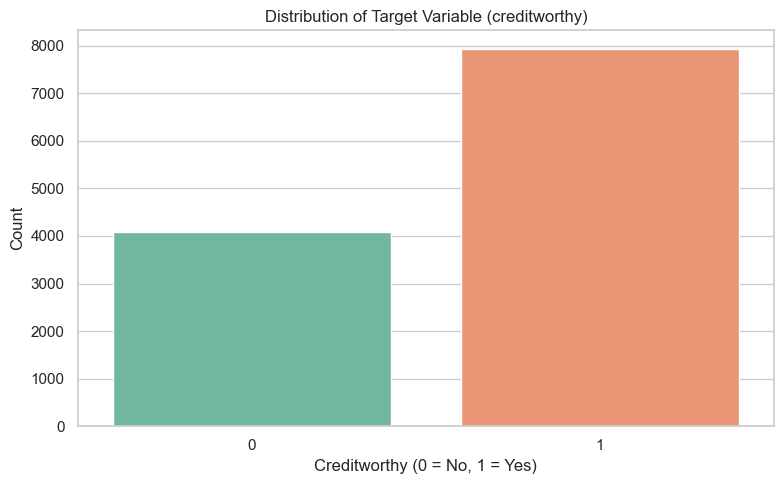

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

fig, ax = plt.subplots()
sns.countplot(x='creditworthy', data=df, palette='Set2', ax=ax)
ax.set_title('Distribution of Target Variable (creditworthy)')
ax.set_xlabel('Creditworthy (0 = No, 1 = Yes)')
ax.set_ylabel('Count')
plt.tight_layout()


C:\Users\hp\AppData\Local\Temp\ipykernel_12744\3002215260.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='creditworthy', y='credit_score', data=df, palette='Set2', ax=ax)


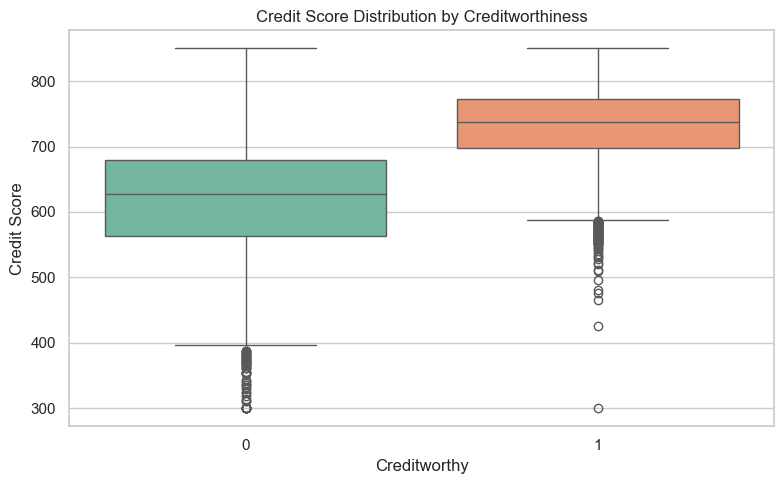

In [20]:
fig, ax = plt.subplots()
sns.boxplot(x='creditworthy', y='credit_score', data=df, palette='Set2', ax=ax)
ax.set_title('Credit Score Distribution by Creditworthiness')
ax.set_xlabel('Creditworthy')
ax.set_ylabel('Credit Score')
plt.tight_layout()

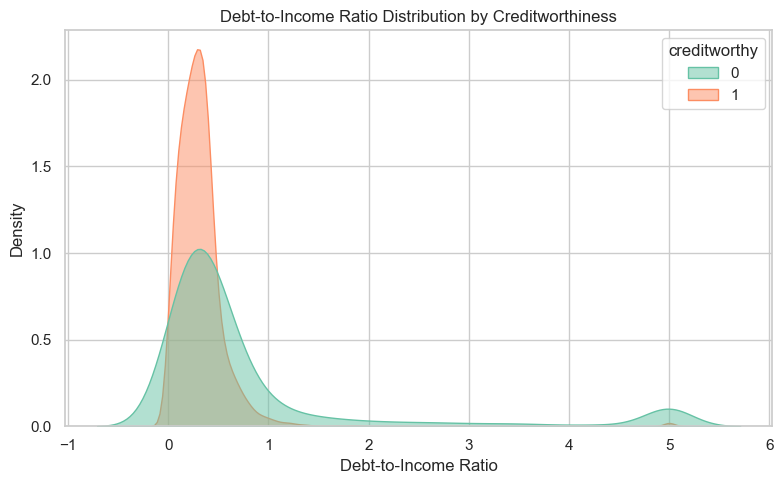

In [21]:
fig, ax = plt.subplots()
sns.kdeplot(data=df, x='debt_to_income_ratio', hue='creditworthy', fill=True, common_norm=False, palette='Set2', alpha=0.5, ax=ax)
ax.set_title('Debt-to-Income Ratio Distribution by Creditworthiness')
ax.set_xlabel('Debt-to-Income Ratio')
ax.set_ylabel('Density')
plt.tight_layout()

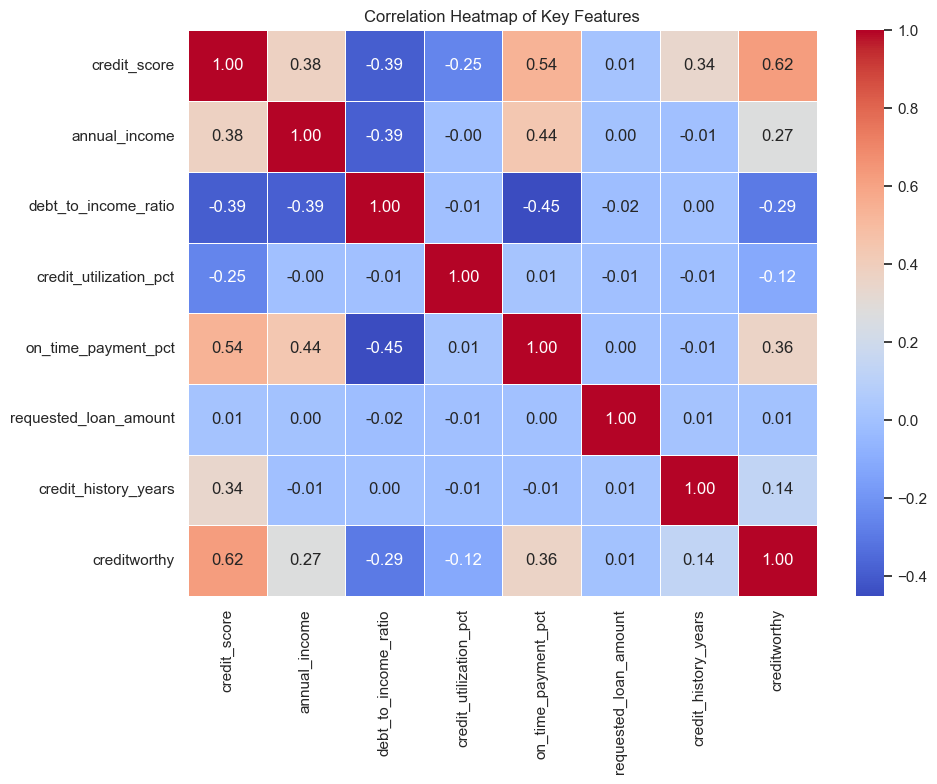

In [22]:
key_features = [
    'credit_score', 'annual_income', 'debt_to_income_ratio', 
    'credit_utilization_pct', 'on_time_payment_pct', 
    'requested_loan_amount', 'credit_history_years', 'creditworthy'
]
corr_matrix = df[key_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=ax)
ax.set_title('Correlation Heatmap of Key Features')
plt.tight_layout()

### FEATURE ENGINEERING

In [23]:
def engineer_features(file_path):
    # 1. Load data
    df = pd.read_csv(file_path)
    print(f"Original shape: {df.shape}")
    
    # 2. Drop unique identifier
    df = df.drop(columns=['customer_id'])
    
    # 3. Create Domain-Specific Features
    # Total Liquid wealth
    df['total_financial_assets'] = df['savings_balance'] + df['checking_balance'] + df['investment_accounts']
    
    # Total historical delinquencies
    df['total_delinquencies'] = df['late_payments_30_days'] + df['late_payments_60_days'] + df['late_payments_90_days']
    
    # Loan amount relative to assets (adding 1 to avoid division by zero)
    df['loan_to_asset_ratio'] = df['requested_loan_amount'] / (df['total_financial_assets'] + 1)
    
    # 4. Ordinal Encoding for Education Level
    education_map = {
        'High School': 0,
        'Associate': 1,
        'Bachelor': 2,
        'Master': 3,
        'PhD': 4
    }
    df['education_level'] = df['education_level'].map(education_map)
    
    # 5. One-Hot Encoding for Nominal Categorical Variables
    nominal_cols = ['employment_status', 'housing_status', 'loan_purpose', 'state']
    df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)
    
    print(f"Engineered shape: {df.shape}")
    return df

# Run the pipeline
processed_df = engineer_features('credit_dataset.csv')

Original shape: (12000, 41)
Engineered shape: (12000, 80)


### Standardization & Data Split

In [25]:
X = processed_df.drop(columns=['creditworthy'])
y = processed_df['creditworthy']

# 2. Stratified Train-Test Split (preserves the 66% vs 34% class balance in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Feature Scaling 
scaler = StandardScaler()
# Fit only on training data to prevent data leakage, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Training set shape: (9600, 79)
Testing set shape: (2400, 79)


## Logistic Regression

In [48]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [49]:
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [50]:
print("--- Baseline Logistic Regression Performance ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")

--- Baseline Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.77      0.64      0.70       815
           1       0.83      0.90      0.87      1585

    accuracy                           0.81      2400
   macro avg       0.80      0.77      0.78      2400
weighted avg       0.81      0.81      0.81      2400

ROC-AUC Score: 0.8694



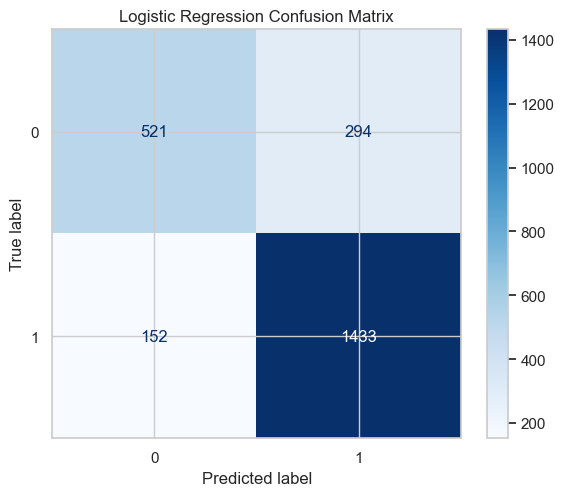

In [51]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', ax=ax)
ax.set_title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

## Decision Tree

In [53]:
# 1. Initialize with growth constraints to prevent overfitting
dt_model = DecisionTreeClassifier(
    max_depth=5,              # Restricts the tree to 5 structural levels down
    min_samples_split=20,     # A node must have at least 20 samples to split further
    random_state=42
)

# 2. Train on UNSCALED data (Trees are scale-invariant)
dt_model.fit(X_train, y_train)

# 3. Predict
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

In [54]:
print("--- Decision Tree Model Evaluation ---")
print(classification_report(y_test, y_pred_dt))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_dt):.4f}")

--- Decision Tree Model Evaluation ---
              precision    recall  f1-score   support

           0       0.77      0.63      0.69       815
           1       0.82      0.90      0.86      1585

    accuracy                           0.81      2400
   macro avg       0.80      0.76      0.78      2400
weighted avg       0.81      0.81      0.80      2400

ROC-AUC Score: 0.8618


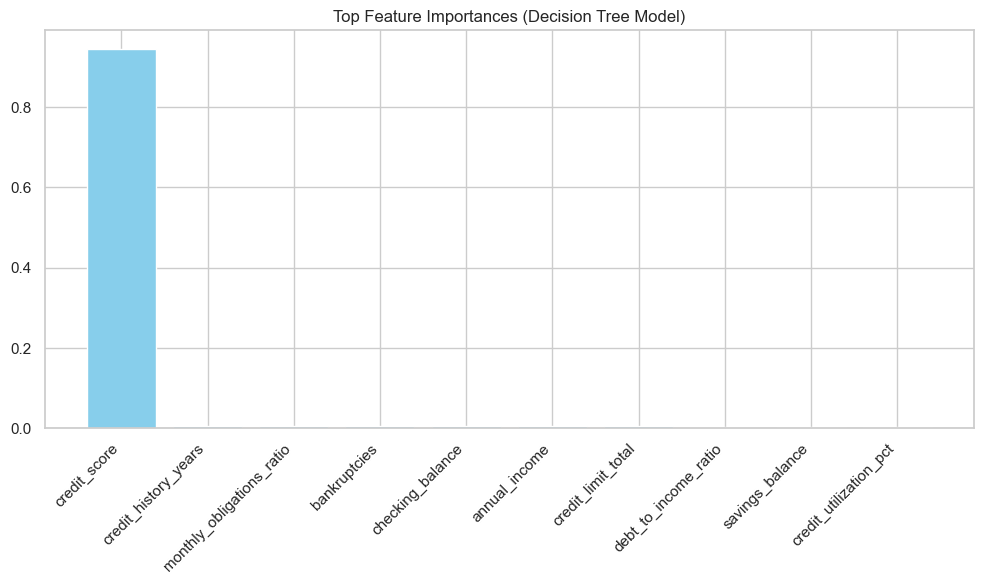

In [56]:
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the top 10 most influential features
plt.figure(figsize=(10, 6))
plt.title("Top Feature Importances (Decision Tree Model)")
plt.bar(range(10), importances[indices[:10]], align="center", color="skyblue")
plt.xticks(range(10), [X.columns[i] for i in indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

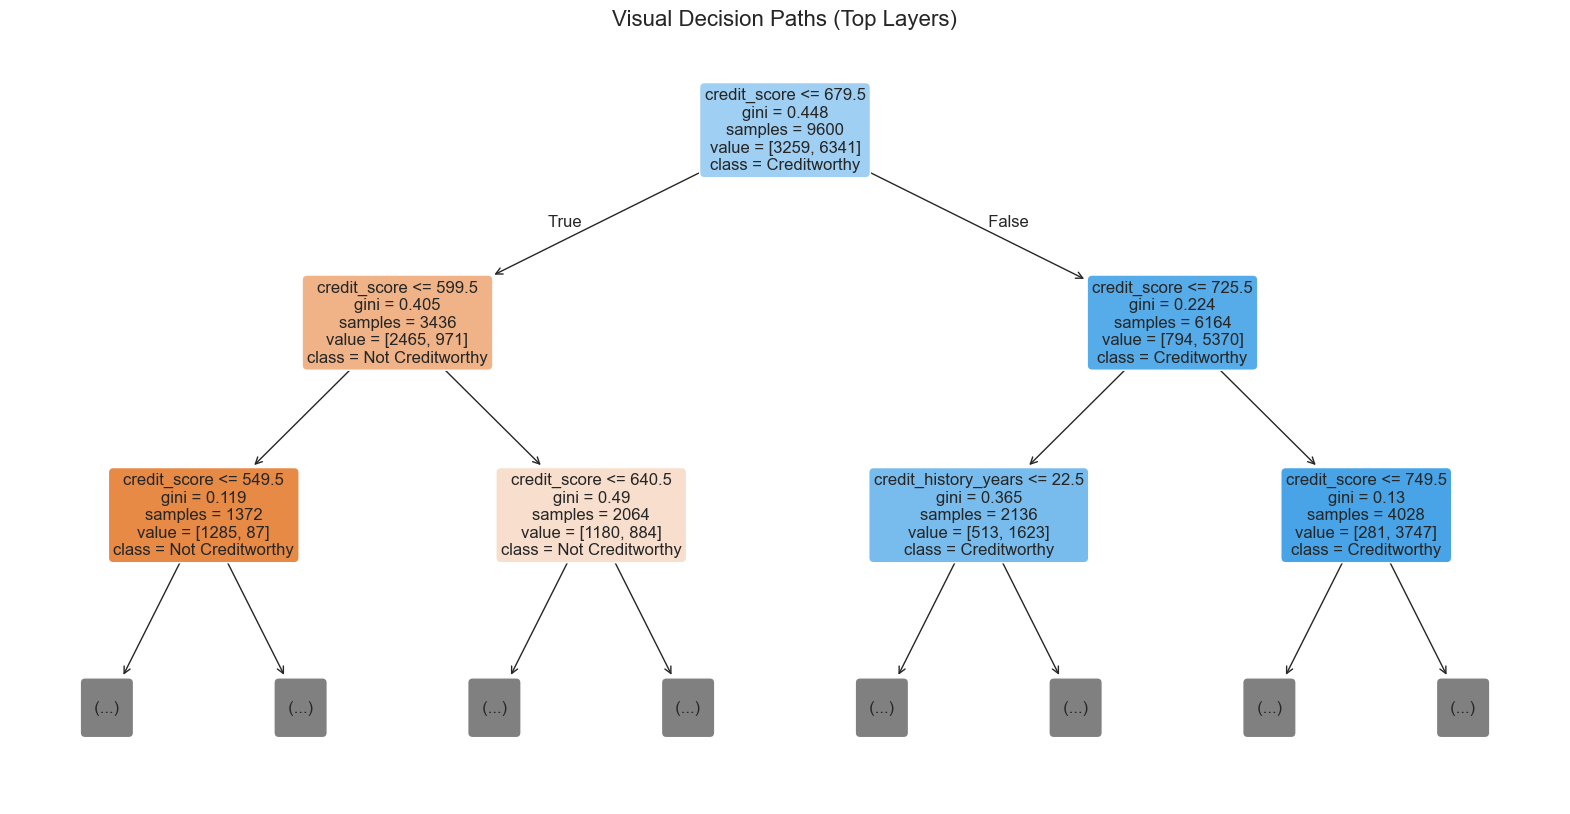

In [57]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model, 
    max_depth=2, # Visualize only the top 2 layers for neatness
    feature_names=X.columns, 
    class_names=['Not Creditworthy', 'Creditworthy'], 
    filled=True, 
    rounded=True,
    fontsize=12
)
plt.title("Visual Decision Paths (Top Layers)", fontsize=16)
plt.show()

## Random Forest

In [59]:
# Initialize Random Forest with regularization to ensure generalizability
rf_model = RandomForestClassifier(
    n_estimators=100,       # Number of individual trees in the forest
    max_depth=10,           # Caps individual tree growth to prevent depth overfitting
    min_samples_split=10,   # Minimum samples required to split an internal node
    random_state=42,
    n_jobs=-1               # Uses all available processor cores
)

# Train the ensemble model
rf_model.fit(X_train, y_train)

# Generate predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [60]:
print("--- Random Forest Model Evaluation ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

--- Random Forest Model Evaluation ---
              precision    recall  f1-score   support

           0       0.78      0.64      0.70       815
           1       0.83      0.91      0.87      1585

    accuracy                           0.81      2400
   macro avg       0.80      0.77      0.78      2400
weighted avg       0.81      0.81      0.81      2400

ROC-AUC Score: 0.8669


## Conclusion:
As the data was imbalanced (2:1), considering f1-score and ROC-AUC Score; almost all 3 models give similar metrics results but with a slight higher score by **Logistic Regression**, it wins.